### Test - Small box evaluations

</b> Author:   </b>  Sam MacKay

### Import relevant files:

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import sys

#add path
sys.path.insert(0, '../../')     # import path/to/synthpy

import src.simulator.config as config
config.jax_init(force_device = "cpu")

import simulator.beam as beam_initialiser
import simulator.domain as d
import simulator.propagator as p
import processing.diagnostics as diag

import importlib
importlib.reload(beam_initialiser)
importlib.reload(d)
importlib.reload(p)
importlib.reload(diag)

Setting top level path for imports: /home/administrator/Programs/synthPy/src

Disabling python multi-threading...
Initialising jax...

Default jax backend: cpu
Available devices: [CpuDevice(id=0), CpuDevice(id=1), CpuDevice(id=2), CpuDevice(id=3), CpuDevice(id=4), CpuDevice(id=5), CpuDevice(id=6), CpuDevice(id=7), CpuDevice(id=8), CpuDevice(id=9), CpuDevice(id=10), CpuDevice(id=11), CpuDevice(id=12), CpuDevice(id=13), CpuDevice(id=14), CpuDevice(id=15)]


/home/administrator/Programs/synthPy/src/simulator/domain.py:661: SyntaxWarning: invalid escape sequence '\ '
  :type ne_0: float, default: 2e23 m\ :sup:`-3`
/home/administrator/Programs/synthPy/src/simulator/domain.py:718: SyntaxWarning: invalid escape sequence '\ '
  :type ne_0: float, default: 1e24 m\ :sup:`-3`
/home/administrator/Programs/synthPy/src/simulator/domain.py:757: SyntaxWarning: invalid escape sequence '\ '
  Load externally generated MxMxM grid of electron density (ne) in m\ :sup:`-3`


<module 'processing.diagnostics' from '/home/administrator/Programs/synthPy/src/processing/diagnostics.py'>

To use the ray tracer, first create a 'domain', load the domain with an electron distribution, calculate electron gradients, initialise a beam, and solve!
\
\
The output can either be plotted, or passed further through ray optics for synthetic diagnostics

In [2]:
extent_x = 5e-3
extent_y = 5e-3

extent_x_2 = 5e-4
extent_y_2 = 5e-4

extent_z = 10e-3

n_cells = 128

probing_extent = extent_z
probing_direction = 'z'

lengths = 2 * np.array([extent_x, extent_y, extent_z])
lengths_2 = 2 * np.array([extent_x_2, extent_y_2, extent_z])

domain = d.ScalarDomain(lengths, n_cells, ne_type = "test_exponential_cos", probing_direction = probing_direction)
domain_2 = d.ScalarDomain(lengths_2, n_cells, ne_type = "test_exponential_cos", probing_direction = probing_direction)

Predicted size in memory of domain: 8.0 MB

Memory prior to domain creation:
 - total : 14.982200622558594 GB
 - free  : 7.142002105712891 GB
 - used  : 7.821296691894531 GB

Est. domain memory limit: 26.400000000000002 MB
 --> inc. +10.0% variance margin

Coordinates have shape of (128, 128, 128) --> no padding required.

Generating test exponential decay periodic -e field...
Predicted size in memory of domain: 8.0 MB

Memory prior to domain creation:
 - total : 14.982200622558594 GB
 - free  : 7.052227020263672 GB
 - used  : 7.911231994628906 GB

Est. domain memory limit: 26.400000000000002 MB
 --> inc. +10.0% variance margin

Coordinates have shape of (128, 128, 128) --> no padding required.

Generating test exponential decay periodic -e field...


Solve gradients, initialise beam, and solve

In [3]:
lwl = 1064e-9

Np = 200000
divergence = 5e-5
ne_extent = probing_extent
beam_type = 'circular'

beam_definition = beam_initialiser.Beam(
    Np, extent_x, divergence, ne_extent,
    probing_direction = probing_direction,
    beam_type = "circular"
)

beam_definition_smallBeam = beam_initialiser.Beam(
    Np, extent_x_2, divergence, ne_extent,
    probing_direction = probing_direction,
    beam_type = "circular"
)

beam_definition_2_orig = beam_initialiser.Beam(
    Np, extent_x, divergence, ne_extent,
    probing_direction = probing_direction,
    beam_type = "circular"
)

beam_definition_2_matching = beam_initialiser.Beam(
    Np, extent_x_2, divergence, ne_extent,
    probing_direction = probing_direction,
    beam_type = "circular"
)

rf, _, duration = p.solve(beam_definition.s0, domain, probing_extent)
rf_smallBeam, _, duration = p.solve(beam_definition_smallBeam.s0, domain, probing_extent) # beam much smaller than domain - is small domain or small beam the issue?
rf_2_orig, _, duration = p.solve(beam_definition_2_orig.s0, domain_2, probing_extent) # domain smaller than beam
rf_2_pot_fix, _, duration = p.solve(beam_definition_2_matching.s0, domain_2, probing_extent) # small beam and domain


Number of domain batches: 1
Number of ray batches: 1

Est. size in memory of rays (1 = 712 B): 135.80322265625 MB
 --> Np = 200000

No need to generate any sections of the domain, batching not utilised.
 --> tracing a depth of 0.01 mm's to the target depth of 0.01 mm's

Running device: cpu, with: 16 cores.
NamedSharding(mesh=Mesh('rows': 16, axis_types=(Auto,)), spec=PartitionSpec('rows', None), memory_kind=unpinned_host)

jax compilation of solver took: 0.0006697177886962891 seconds
Completed ray trace in 5.498 seconds.

Parallelised output has resulting 3D matrix of form: [batch_count, (save_points_per_region - 1) * ScalarDomain.region_count, 9]: (200000, 2, 9)
 - 2 to account for the start and end results (typical, can be greater if set)
 - 9 containing the 3 position and velocity components, amplitude, phase and polarisation
 - If batch_count is lower than expected, this is likely due to jax's forced integer batch sharding requirement over cpu cores.

We slice the results and tran

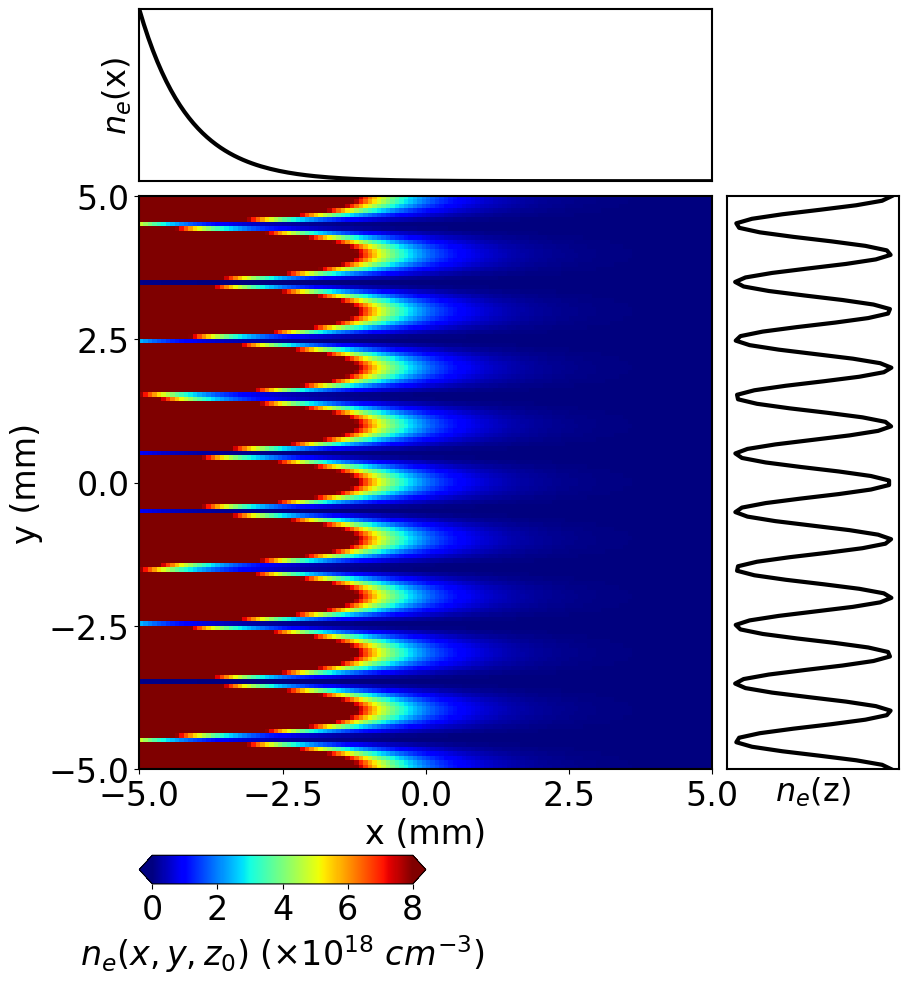

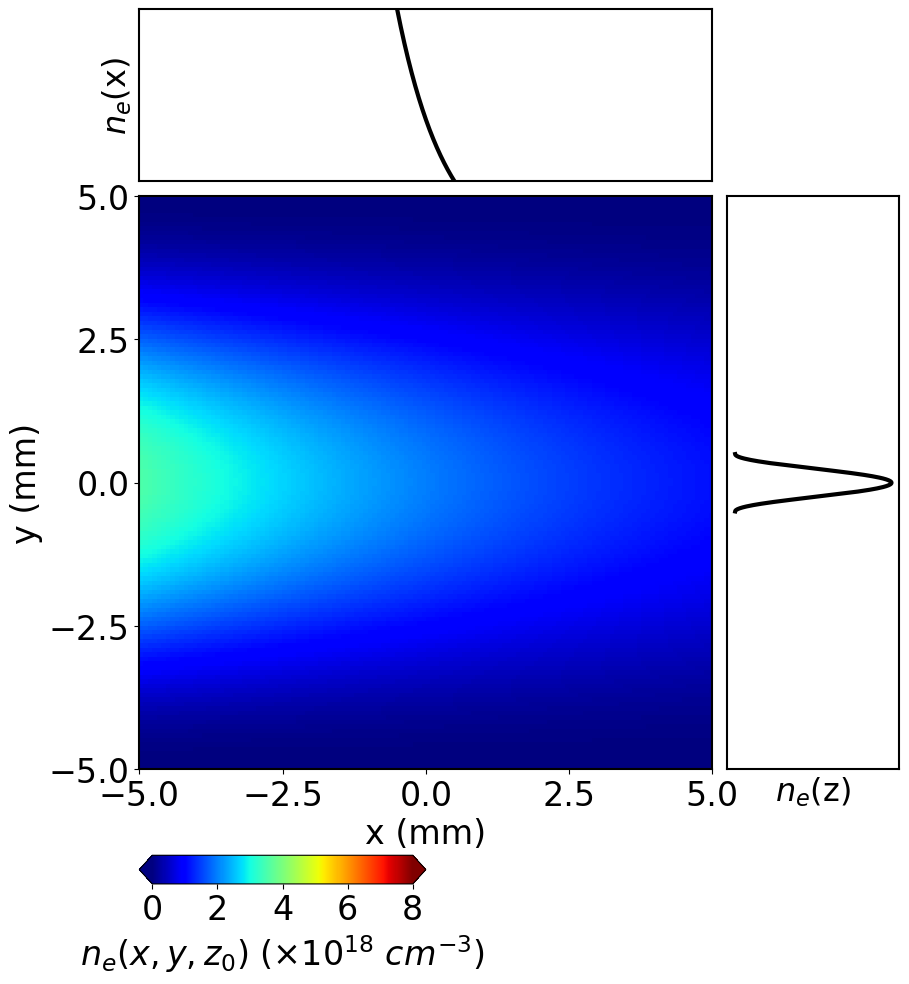

In [4]:
from mpl_toolkits.axes_grid1 import make_axes_locatable
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

def graph_domain(domain, *, save = False):
    fig, ax = plt.subplots(figsize = (9.5, 9.5))
    fig.subplots_adjust(.15, .15, .95, .95, hspace = 0.5)

    im = ax.imshow(domain.ne[:,:,0].T/1e24, cmap = 'jet', origin = 'lower', extent = [-5, 5, -5, 5], clim = [0, 8])
    ax.set_xlim(-5, 5)
    ax.set_ylim(-5, 5)
    ax.set_xticks([-5, -2.5, 0, 2.5, 5])
    ax.set_yticks([-5, -2.5, 0, 2.5, 5])

    axins1 = inset_axes(
        ax,
        width="50%",  # width: 50% of parent_bbox width
        height="5%",  # height: 5%
        loc="lower right",
        bbox_to_anchor = (-0.5, -0.2, 1, 1),
        bbox_transform = ax.transAxes,
        borderpad = 0,
    )

    axins1.xaxis.set_ticks_position("bottom")
    cbar = plt.colorbar(im, cax=axins1, ticks=[0, 2, 4, 6, 8], shrink = 0.4, orientation="horizontal", extend='both')
    cbar.set_label(r'$ n_e(x, y, z_0)$ ($\times 10^{18}$ $cm^{-3}$)', fontsize = 24)
    cbar.ax.tick_params(labelsize = 24)

    ax.set_xlabel('x (mm)', fontsize = 24)
    ax.set_ylabel('y (mm)', fontsize = 24)

    divider = make_axes_locatable(ax)
    axvert  = divider.append_axes('right', size = '30%', pad = 0.15)
    axhoriz = divider.append_axes('top',   size = '30%', pad = 0.15)

    profile_vert    =   domain.ne[:, :, 0].T.sum(axis = 0)
    profile_vert    =   (profile_vert - profile_vert.min() ) / (profile_vert.max() - profile_vert.min())
    axhoriz.plot(domain.x, profile_vert, lw = 3, c = 'k', alpha = 1)
    axhoriz.set_xlim(-5e-3, 5e-3)
    axhoriz.set_ylim(0, 1)
    axhoriz.set_ylabel(r'$n_e$(x)', fontsize = 23)

    profile_hor     =   domain.ne[:, :, 0].T.sum(axis = 1)
    profile_hor     =   (profile_hor - profile_hor.min() ) / (profile_hor.max() - profile_hor.min())
    profile_hor_theory  =  profile_hor
    axvert.plot(profile_hor, domain.y, lw = 3, c = 'k', alpha = 1)
    axvert.set_ylim(-5e-3, 5e-3)
    axvert.set_xlabel(r'$n_e$(z)', fontsize = 23)

    ax.tick_params(axis = 'both', labelsize = 24)

    axvert.set_xticks([])
    axhoriz.set_yticks([])
    axvert.set_yticks([])
    axhoriz.set_xticks([])

    for axis in ["top", "bottom", "left", "right"]:
        ax.spines[axis].set_linewidth(1.5)
        axvert.spines[axis].set_linewidth(1.5)
        axhoriz.spines[axis].set_linewidth(1.5)

    # ax.text(4, 4.2, s = 'a)', c = 'w', fontsize = 30)

    # save Figure
    if save:
        from datetime import datetime
        fig.savefig('./analytical 2D electron density distribution - ' + datetime.now().strftime("%Y%m%d-%H%M%S") + '.png', bbox_inches = 'tight', dpi = 600)

graph_domain(domain)
graph_domain(domain_2)

Text(0, 0.5, 'e- density')

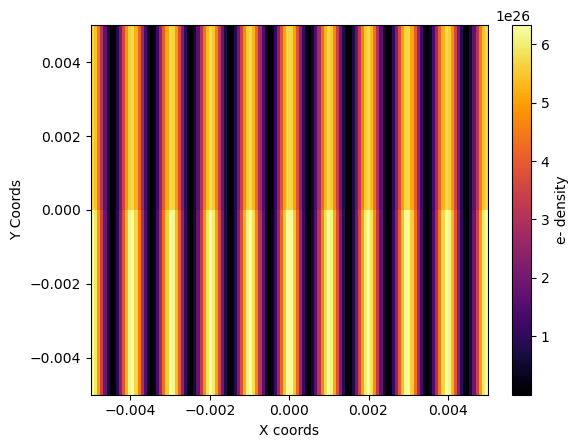

In [ ]:
xy = domain.ne[:, :, -1]

heatmap, ax = plt.subplots()

im = ax.imshow([xy[0], xy[1]], cmap='inferno', extent = [domain.x[0], domain.x[-1], domain.y[0], domain.y[-1]], interpolation='nearest', origin = 'lower', aspect = 'auto')
ax.set(xlabel='X coords', ylabel='Y Coords')

cbar = heatmap.colorbar(im)
cbar.ax.set_ylabel('e- density')


200000 rays received, 126943 incident on the first lens.
 --> 36.5 % of rays wasted!

rf size expected: [126943. 126943.]
rf after clearing nan's: [126943. 126943.]


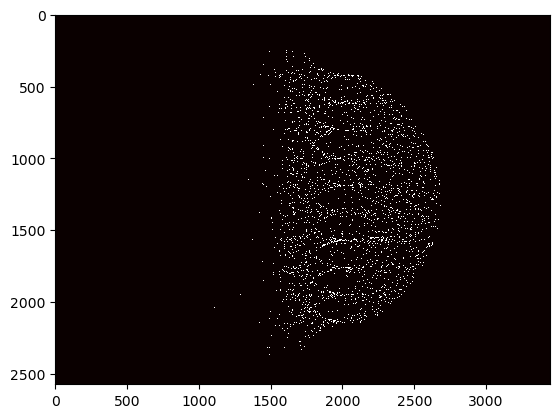

In [ ]:
#in the diagnostic initialisation, details on the lens configurations, and detector dimensions can be specified
refractometer = diag.Refractometry(lwl, rf)
# cam't clear_mem if you want to generate other graphs afterwards
refractometer.plot_rays(bin_scale = 1, clear_mem = False)

#information accessed by .H(istogram) , e.g plt.imshow(refractometer.H)

#plt.imshow(refractometer.H, cmap='hot', interpolation='nearest', clim = (0, 2))
plt.imshow(refractometer.H, cmap = 'hot', interpolation = 'nearest', clim = (0.5, 1))


200000 rays received, 193972 incident on the first lens.
 --> 3.01 % of rays wasted!

rf size expected: [193972. 193972.]
rf after clearing nan's: [193972. 193972.]


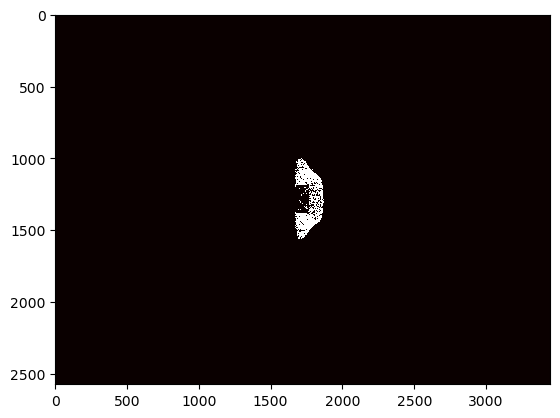

In [ ]:
refractometer_smallBeam = diag.Refractometry(lwl, rf_smallBeam)
refractometer_smallBeam.plot_rays(bin_scale = 1, clear_mem = False)

plt.imshow(refractometer_smallBeam.H, cmap = 'hot', interpolation = 'nearest', clim = (0.5, 1))


200000 rays received, 199916 incident on the first lens.
 --> 0.042 % of rays wasted!

rf size expected: [199916. 199916.]
rf after clearing nan's: [199916. 199916.]


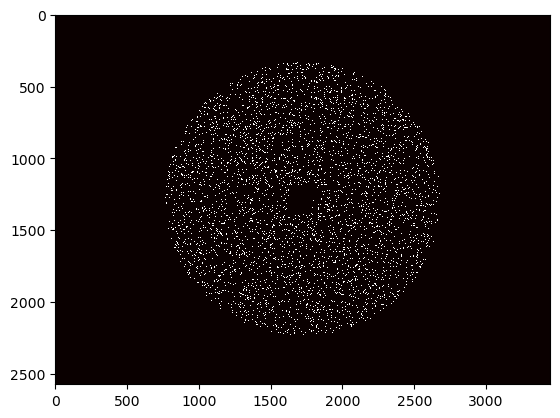

In [ ]:
refractometer_2_orig = diag.Refractometry(lwl, rf_2_orig)
refractometer_2_orig.plot_rays(bin_scale = 1, clear_mem = False)

plt.imshow(refractometer_2_orig.H, cmap = 'hot', interpolation = 'nearest', clim = (0.5, 1))


200000 rays received, 192167 incident on the first lens.
 --> 3.9199998 % of rays wasted!

rf size expected: [192167. 192167.]
rf after clearing nan's: [192167. 192167.]


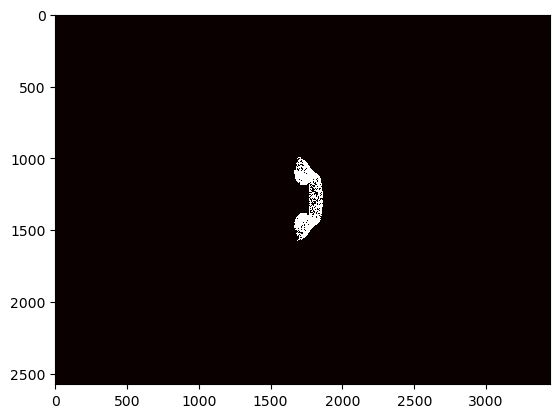

In [ ]:
refractometer_2_pot_fix = diag.Refractometry(lwl, rf_2_pot_fix)
refractometer_2_pot_fix.plot_rays(bin_scale = 1, clear_mem = False)

plt.imshow(refractometer_2_pot_fix.H, cmap = 'hot', interpolation = 'nearest', clim = (0.5, 1))


200000 rays received, 126943 incident on the first lens.
 --> 36.5 % of rays wasted!


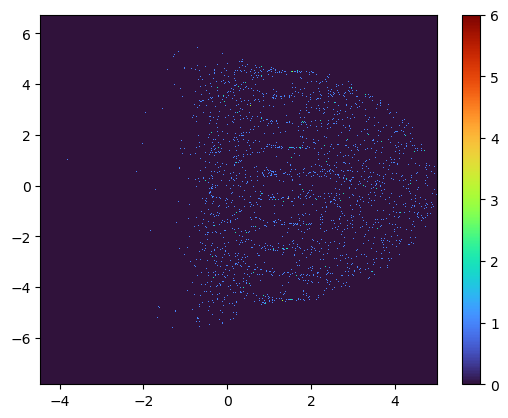

In [ ]:
converter = diag.Refractometry(lwl, rf)
rf_mm = converter.r0
del converter

from shared.utils import heat_plot
heat_plot(rf_mm[0], rf_mm[2])


200000 rays received, 193972 incident on the first lens.
 --> 3.01 % of rays wasted!


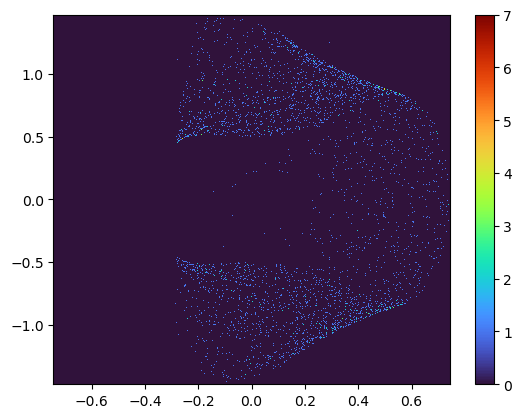

In [ ]:
converter_smallBeam = diag.Refractometry(lwl, rf_smallBeam)
rf_mm_smallBeam = converter_smallBeam.r0
del converter_smallBeam

from shared.utils import heat_plot
heat_plot(rf_mm_smallBeam[0], rf_mm_smallBeam[2])


200000 rays received, 199916 incident on the first lens.
 --> 0.042 % of rays wasted!


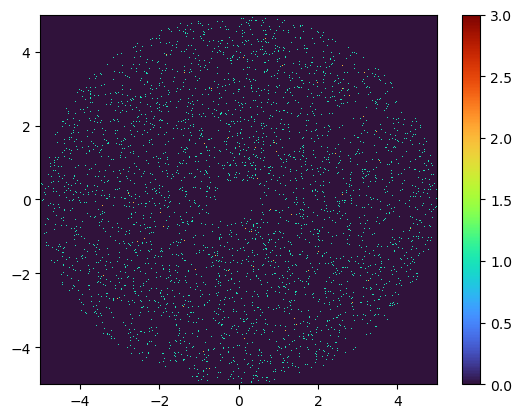

In [ ]:
converter_2_orig = diag.Refractometry(lwl, rf_2_orig)
rf_mm_2_orig = converter_2_orig.r0
del converter_2_orig

from shared.utils import heat_plot
heat_plot(rf_mm_2_orig[0], rf_mm_2_orig[2])


200000 rays received, 192167 incident on the first lens.
 --> 3.9199998 % of rays wasted!


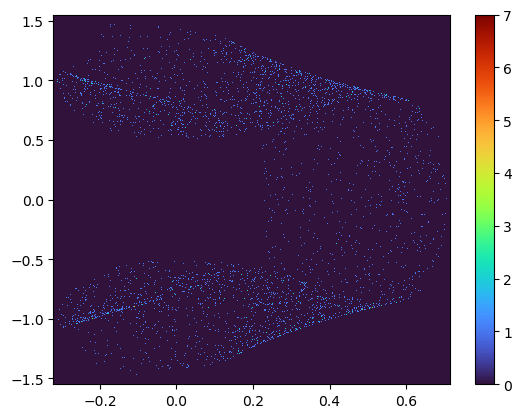

In [ ]:
converter_2_pot_fix = diag.Refractometry(lwl, rf_2_pot_fix)
rf_mm_2_pot_fix = converter_2_pot_fix.r0
del converter_2_pot_fix

from shared.utils import heat_plot
heat_plot(rf_mm_2_pot_fix[0], rf_mm_2_pot_fix[2])

Pass through ray optics: For Shadowgaphy, Schlieren, or Refractometry:

In [ ]:
refractometer = diag.Refractometry(lwl, rf)
refractometer.incoherent_solve()
refractometer.histogram(bin_scale = 1, clear_mem = False)

plt.imshow(refractometer.H, cmap = 'hot', interpolation = 'nearest', clim = (0.5, 1))


200000 rays received, 126943 incident on the first lens.
 --> 36.5 % of rays wasted!

rf size expected: [126943. 126943.]
rf after clearing nan's: [126943. 126943.]



200000 rays received, 193893 incident on the first lens.
 --> 3.05 % of rays wasted!

rf size expected: [193893. 193893.]
rf after clearing nan's: [193893. 193893.]


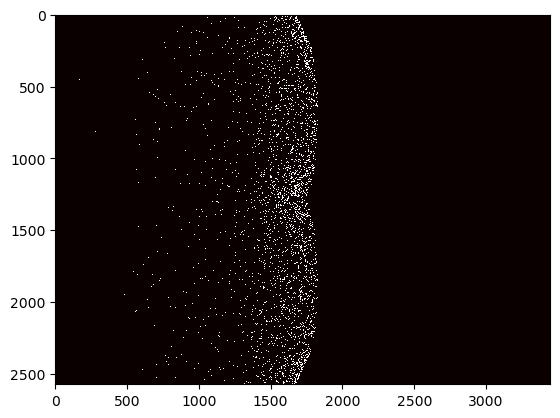

In [ ]:
refractometer_smallBeam = diag.Refractometry(lwl, rf_smallBeam)
refractometer_smallBeam.incoherent_solve()
refractometer_smallBeam.histogram(bin_scale = 1, clear_mem = False)

plt.imshow(refractometer_smallBeam.H, cmap = 'hot', interpolation = 'nearest', clim = (0.5, 1))


200000 rays received, 199916 incident on the first lens.
 --> 0.042 % of rays wasted!

rf size expected: [199916. 199916.]
rf after clearing nan's: [199916. 199916.]


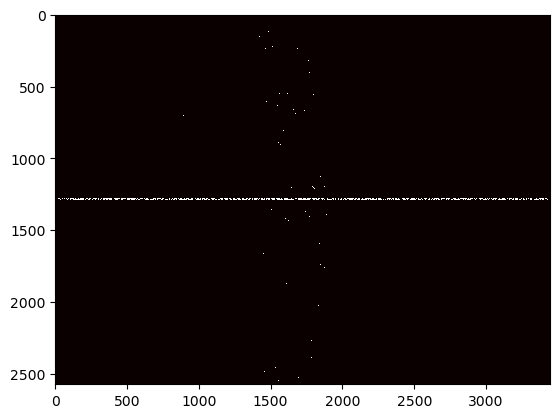

In [ ]:
refractometer_2_orig = diag.Refractometry(lwl, rf_2_orig)
refractometer_2_orig.incoherent_solve()
refractometer_2_orig.histogram(bin_scale = 1, clear_mem = False)

plt.imshow(refractometer_2_orig.H, cmap = 'hot', interpolation = 'nearest', clim = (0.5, 1))


200000 rays received, 192199 incident on the first lens.
 --> 3.8999999 % of rays wasted!

rf size expected: [192199. 192199.]
rf after clearing nan's: [192199. 192199.]


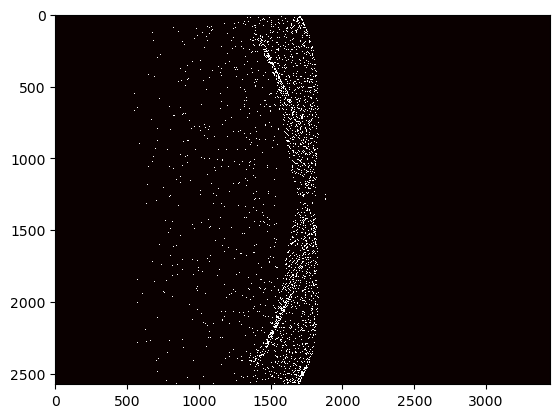

In [ ]:
refractometer_2_pot_fix = diag.Refractometry(lwl, rf_2_pot_fix)
refractometer_2_pot_fix.incoherent_solve()
refractometer_2_pot_fix.histogram(bin_scale = 1, clear_mem = False)

plt.imshow(refractometer_2_pot_fix.H, cmap = 'hot', interpolation = 'nearest', clim = (0.5, 1))


200000 rays received, 126873 incident on the first lens.
 --> 36.600002 % of rays wasted!

rf size expected: [126873. 126873.]
rf after clearing nan's: [126873. 126873.]


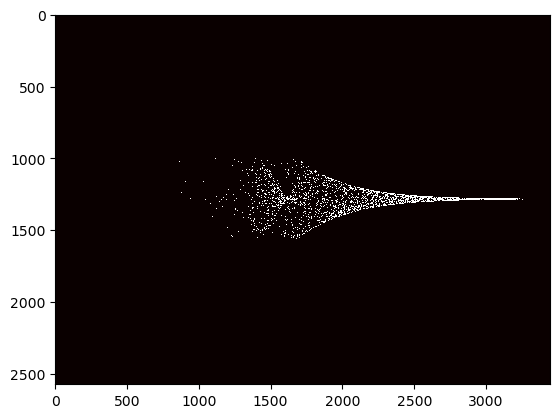

In [ ]:
refractometer = diag.Refractometry(lwl, rf, L = 50)
refractometer.incoherent_solve()
refractometer.histogram(bin_scale = 1, clear_mem = False)

plt.imshow(refractometer.H, cmap = 'hot', interpolation = 'nearest', clim = (0.5, 1))


200000 rays received, 193893 incident on the first lens.
 --> 3.05 % of rays wasted!

rf size expected: [193893. 193893.]
rf after clearing nan's: [193893. 193893.]


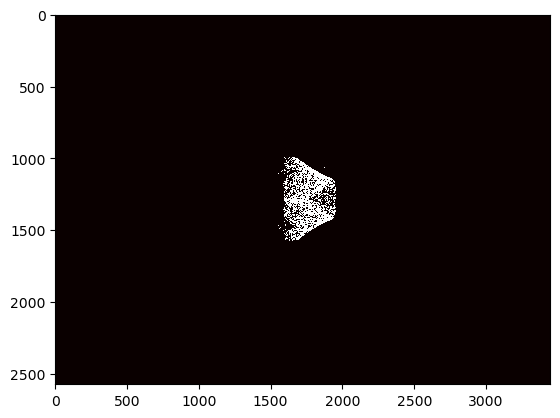

In [ ]:
refractometer_smallBeam = diag.Refractometry(lwl, rf_smallBeam, L = 50)
refractometer_smallBeam.incoherent_solve()
refractometer_smallBeam.histogram(bin_scale = 1, clear_mem = False)

plt.imshow(refractometer_smallBeam.H, cmap = 'hot', interpolation = 'nearest', clim = (0.5, 1))

In [ ]:
refractometer_2_orig = diag.Refractometry(lwl, rf_2_orig, L = 50)
refractometer_2_orig.incoherent_solve()
refractometer_2_orig.histogram(bin_scale = 1, clear_mem = False)

plt.imshow(refractometer_2_orig.H, cmap = 'hot', interpolation = 'nearest', clim = (0.5, 1))


200000 rays received, 199916 incident on the first lens.
 --> 0.042 % of rays wasted!

rf size expected: [199916. 199916.]
rf after clearing nan's: [199916. 199916.]



200000 rays received, 192135 incident on the first lens.
 --> 3.9299998 % of rays wasted!

rf size expected: [192135. 192135.]
rf after clearing nan's: [192135. 192135.]


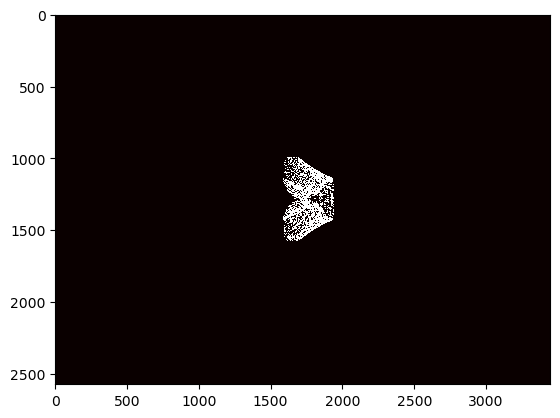

In [ ]:
refractometer_2_pot_fix = diag.Refractometry(lwl, rf_2_pot_fix, L = 50)
refractometer_2_pot_fix.incoherent_solve()
refractometer_2_pot_fix.histogram(bin_scale = 1, clear_mem = False)

plt.imshow(refractometer_2_pot_fix.H, cmap = 'hot', interpolation = 'nearest', clim = (0.5, 1))


200000 rays received, 127486 incident on the first lens.
 --> 36.3 % of rays wasted!

rf size expected: [127486. 127486.]
rf after clearing nan's: [127486. 127486.]


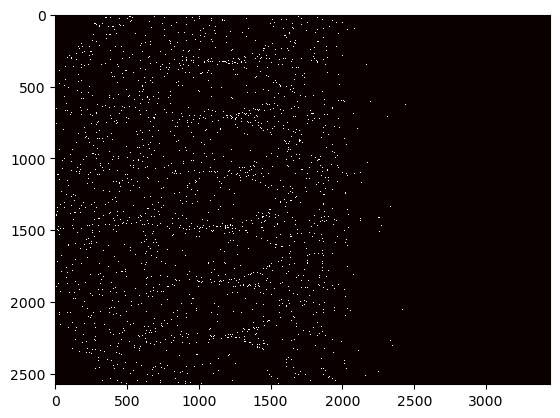

In [ ]:
shadowgrapher = diag.Shadowgraphy(lwl, rf)
shadowgrapher.single_lens_solve()
shadowgrapher.histogram(bin_scale = 1, clear_mem = False)

plt.imshow(shadowgrapher.H, cmap = 'hot', interpolation = 'nearest', clim = (0.5, 1))


200000 rays received, 194036 incident on the first lens.
 --> 2.98 % of rays wasted!

rf size expected: [194036. 194036.]
rf after clearing nan's: [194036. 194036.]


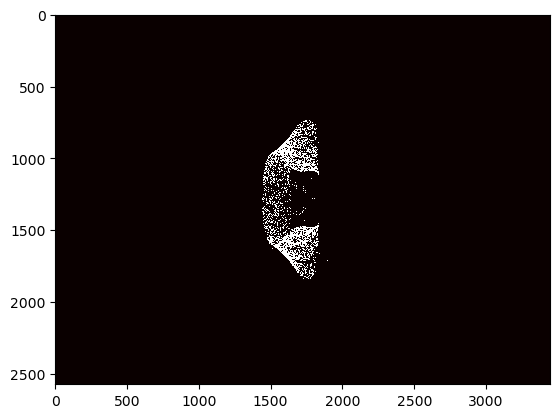

In [ ]:
shadowgrapher_smallBeam = diag.Shadowgraphy(lwl, rf_smallBeam)
shadowgrapher_smallBeam.single_lens_solve()
shadowgrapher_smallBeam.histogram(bin_scale = 1, clear_mem = False)

plt.imshow(shadowgrapher_smallBeam.H, cmap = 'hot', interpolation = 'nearest', clim = (0.5, 1))


200000 rays received, 199903 incident on the first lens.
 --> 0.048499998 % of rays wasted!

rf size expected: [199903. 199903.]
rf after clearing nan's: [199903. 199903.]


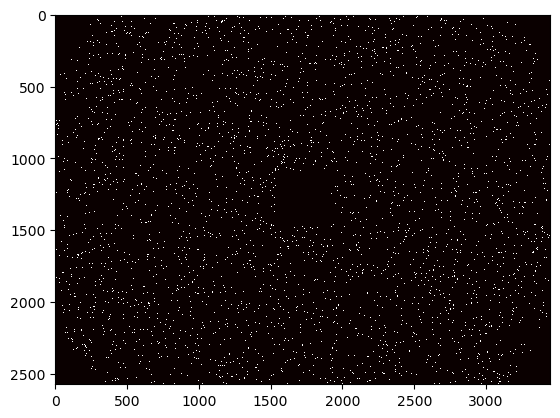

In [ ]:
shadowgrapher_2_orig = diag.Shadowgraphy(lwl, rf_2_orig)
shadowgrapher_2_orig.single_lens_solve()
shadowgrapher_2_orig.histogram(bin_scale = 1, clear_mem = False)

plt.imshow(shadowgrapher_2_orig.H, cmap = 'hot', interpolation = 'nearest', clim = (0.5, 1))


200000 rays received, 192135 incident on the first lens.
 --> 3.9299998 % of rays wasted!

rf size expected: [192135. 192135.]
rf after clearing nan's: [192135. 192135.]


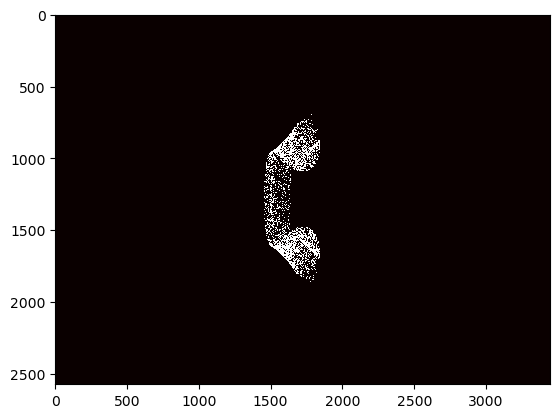

In [ ]:
shadowgrapher_2_pot_fix = diag.Shadowgraphy(lwl, rf_2_pot_fix)
shadowgrapher_2_pot_fix.single_lens_solve()
shadowgrapher_2_pot_fix.histogram(bin_scale = 1, clear_mem = False)

plt.imshow(shadowgrapher_2_pot_fix.H, cmap = 'hot', interpolation = 'nearest', clim = (0.5, 1))


200000 rays received, 127486 incident on the first lens.
 --> 36.3 % of rays wasted!

rf size expected: [127486. 127486.]
rf after clearing nan's: [76661. 76661.]


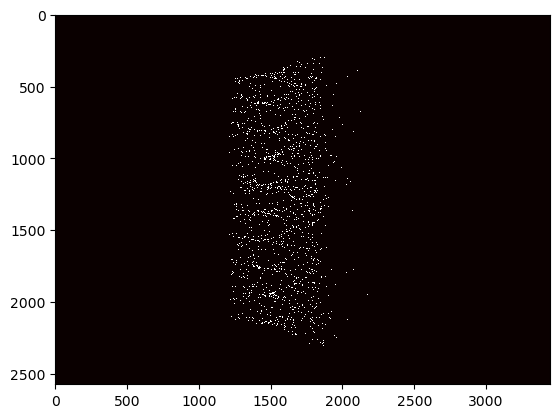

In [ ]:
schlierener = diag.Schlieren(lwl, rf)
schlierener.DF_solve()
schlierener.histogram(bin_scale = 1, clear_mem = True)

plt.imshow(schlierener.H, cmap = 'hot', interpolation = 'nearest', clim = (0.5, 1))


200000 rays received, 194036 incident on the first lens.
 --> 2.98 % of rays wasted!

rf size expected: [194036. 194036.]
rf after clearing nan's: [182278. 182278.]


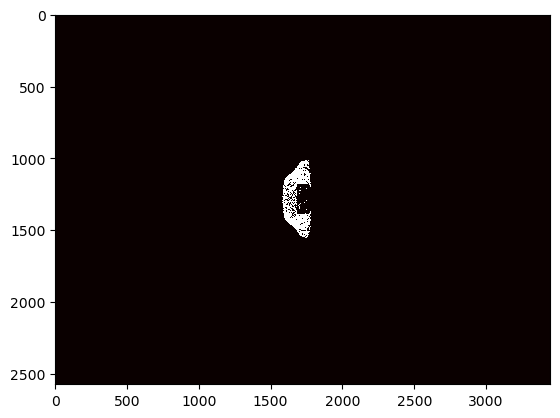

In [ ]:
schlierener_smallBeam = diag.Schlieren(lwl, rf_smallBeam)
schlierener_smallBeam.DF_solve()
schlierener_smallBeam.histogram(bin_scale = 1, clear_mem = True)

plt.imshow(schlierener_smallBeam.H, cmap = 'hot', interpolation = 'nearest', clim = (0.5, 1))


200000 rays received, 199903 incident on the first lens.
 --> 0.048499998 % of rays wasted!

rf size expected: [199903. 199903.]
rf after clearing nan's: [2359. 2359.]


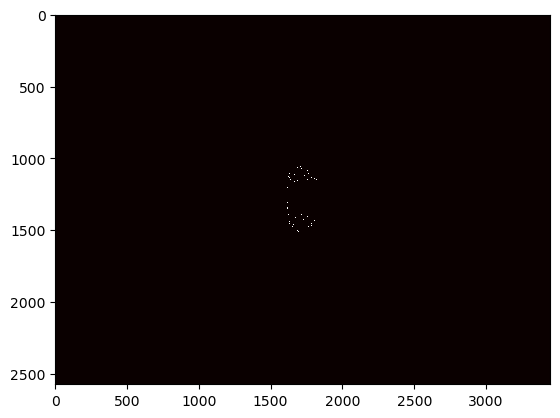

In [ ]:
schlierener_2_orig = diag.Schlieren(lwl, rf_2_orig)
schlierener_2_orig.DF_solve()
schlierener_2_orig.histogram(bin_scale = 1, clear_mem = True)

plt.imshow(schlierener_2_orig.H, cmap = 'hot', interpolation = 'nearest', clim = (0.5, 1))


200000 rays received, 192135 incident on the first lens.
 --> 3.9299998 % of rays wasted!

rf size expected: [192135. 192135.]
rf after clearing nan's: [186513. 186513.]


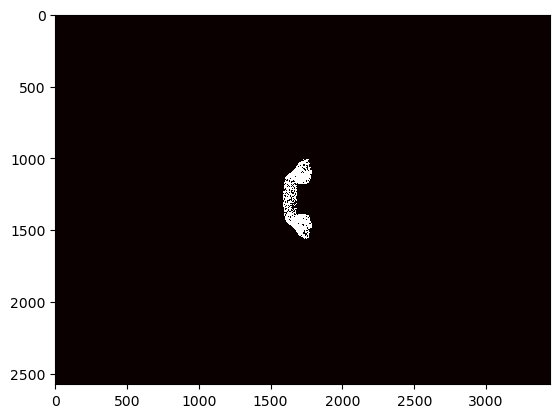

In [ ]:
schlierener_2_pot_fix = diag.Schlieren(lwl, rf_2_pot_fix)
schlierener_2_pot_fix.DF_solve()
schlierener_2_pot_fix.histogram(bin_scale = 1, clear_mem = True)

plt.imshow(schlierener_2_pot_fix.H, cmap = 'hot', interpolation = 'nearest', clim = (0.5, 1))